In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Make model/ and parameter_scan/ importable
sys.path.insert(0, os.path.abspath('../model'))
sys.path.insert(0, os.path.abspath('.'))

from xso.parscans import run_xso_parscan,run_xso_stabilityscan

from cariaco_ssm_setup import model, model_setup, phyto_esd, zoo_esd
from cariaco_obs import load_cariaco_targets
from parscan_utils import (
    compute_cost_grid, find_best_fit, get_default_from_setup, extract_steady_state_seed,
)
from parscan_plots import (
    plot_cost_heatmap,
    plot_model_vs_obs_boxplots, summarize_best_fit,
)

In [2]:
REGIME = 'all'
obs_vec, labels, bin_defs, monthly_df, forcing = load_cariaco_targets(regime=REGIME)

print(f"Observation targets (regime='{REGIME}'):")
for lab, val in zip(labels, obs_vec):
    print(f"  {lab:20s}: {val:.5f}")
print(f"Months in filtered dataset: {len(monthly_df)}")
print(f"Regime forcing:")
print(f"  Inflow__FN = {forcing['Inflow__FN']:.4f}  mmol N m-2 d-1")
print(f"  Inflow__de = {forcing['Inflow__de']:.2f}  m")
print(f"  (F_N/d_e   = {forcing['Inflow__FN']/forcing['Inflow__de']:.6f}  mmol N m-3 d-1)")

Observation targets (regime='all'):
  Pico (<2 µm)        : 0.09698
  Nano (2-20 µm)      : 0.08512
  Micro (>20 µm)      : 0.19977
  Zoo >200 µm         : 0.05938
  Zoo >500 µm         : 0.03302
  NO3                 : 1.46705
  PP                  : 0.43247
  Export              : 3.18267
Months in filtered dataset: 255
Regime forcing:
  Inflow__FN = 2.6834  mmol N m-2 d-1
  Inflow__de = 45.58  m
  (F_N/d_e   = 0.058877  mmol N m-3 d-1)


In [3]:
# from setup defaults d_e is 50.0; cariaco_obs.py forcing overrides this
# with the regime mean (~45.58). Pop FN since it's now the scan axis;
# keep d_e since we're not varying box geometry.
forcing.pop('Inflow__FN', None)

forcing['GGE__gge']                 = 0.17416  # Scan 1
forcing['GGE__f_egest_D']           = 0.55602  # Scan 2
forcing['DetritusRemin__k_remin']   = 0.07590  # Scan 2
forcing['PhytoMortality__f_mort_D'] = 0.47651  # Scan 4
# Grazing__KsZ NOT here — it's the scan axis

In [15]:
# Which parameters to scan, their ranges, and grid resolution
#
# FN × KsZ — productivity vs. grazing-pressure plane.
# - FN has never been varied in prior scans: it's been pinned to the
#   regime-mean from load_cariaco_targets ('all' regime ≈ 2.67). This
#   scan exposes the productivity axis. Range below brackets relaxed
#   and upwelling regime extremes with headroom; refine against
#   load_cariaco_targets(regime='upwelling' / 'relaxed') if desired.
# - KsZ ∈ [0.3, 10]: Hansen 1997 empirical range, Stock central 3.0.
#   Has pinned at 0.3 in every scan since the GGE refactor — this scan
#   tests whether higher FN unpins it.
P1_NAME   = 'Inflow__FN'
P1_LABEL  = 'New nutrient flux F_N (mmol N m⁻² d⁻¹)'
P1_VALUES = np.logspace(np.log10(0.5), np.log10(35.0), 30)
P2_NAME   = 'Grazing__KsZ'
P2_LABEL  = 'Zoo half-saturation K_sZ (mmol N m⁻³)'
P2_VALUES = np.logspace(np.log10(0.3), np.log10(10.0), 30)
# Scan runtime settings
N_PROCESSES = 20
AVG_WINDOW  = 1000   # days at tail of IVP to average for steady-state cost
print(f"2D scan: {P1_NAME} ({len(P1_VALUES)} pts)  x  {P2_NAME} ({len(P2_VALUES)} pts)")
print(f"Total runs: {len(P1_VALUES) * len(P2_VALUES)}")
print(f"  FN spans {P1_VALUES.min():.3f} – {P1_VALUES.max():.3f} mmol N m⁻² d⁻¹ "
      f"(log-spaced; brackets CARIACO regime extremes; "
      f"'all'-regime mean ≈ 2.67)")
print(f"  KsZ spans {P2_VALUES.min():.3f} – {P2_VALUES.max():.3f} mmol N m⁻³ "
      f"(log-spaced; Hansen 1997 empirical range, Stock central 3.0)")

2D scan: Inflow__FN (30 pts)  x  Grazing__KsZ (30 pts)
Total runs: 900
  FN spans 0.500 – 35.000 mmol N m⁻² d⁻¹ (log-spaced; brackets CARIACO regime extremes; 'all'-regime mean ≈ 2.67)
  KsZ spans 0.300 – 10.000 mmol N m⁻³ (log-spaced; Hansen 1997 empirical range, Stock central 3.0)


In [16]:
scan_results = run_xso_parscan(
    model_file_name='cariaco_ssm_setup',
    model_name='model',
    model_setup_name='model_setup_slim',
    param_name=P1_NAME,
    param_values=P1_VALUES,
    param_name2=P2_NAME,
    param_values2=P2_VALUES,
    processes=N_PROCESSES,
    fixed_overrides=forcing,
    postprocess_name='avg_tail',
    postprocess_kwargs={'avg_window': AVG_WINDOW},
)

PROGRESS: Completed 30/30 outer points. (Inflow__FN = 35.0).

2D Scan complete. Total Time taken: 387.4606 seconds.


In [17]:
seed_ds, iv_map = extract_steady_state_seed(scan_results, avg_window=AVG_WINDOW)


stability_results = run_xso_stabilityscan(
    model_file_name='cariaco_ssm_setup',
    model_name='model',
    model_setup_name='model_setup_stability',
    param_name=P1_NAME,
    param_values=P1_VALUES,
    param_name2=P2_NAME,
    param_values2=P2_VALUES,
    processes=N_PROCESSES,
    fixed_overrides=forcing,
    initial_values_ds=seed_ds,
    iv_mapping=iv_map,
)

PROGRESS: Completed 30/30 outer points. (Inflow__FN = 19.479228987977258).

2D Stability Scan complete. Total Time taken: 6.68908 seconds.


In [18]:
cost_grid, model_grid = compute_cost_grid(
    stability_results,
    phyto_esd=phyto_esd,
    zoo_esd=zoo_esd,
    obs_vec=obs_vec,
    bin_definitions=bin_defs,
    dim1_name=P1_NAME,
    dim2_name=P2_NAME,    avg_window=None,
    neg_tolerance=1e-6,
    clip_small_negatives=True,
    require_stable=False,
)

In [19]:
best = find_best_fit(cost_grid, model_grid, scan_results, P1_NAME, P2_NAME)

default = {
    'val1': get_default_from_setup(model_setup, P1_NAME),
    'val2': get_default_from_setup(model_setup, P2_NAME),
}

title_info = (f"{P1_NAME}={best['val1']:.4f}, "
              f"{P2_NAME}={best['val2']:.4f}, "
              f"cost={best['cost']:.3f}")

print(f"\n--- Best fit ---")
print(f"  {P1_LABEL}: {best['val1']:.5f}")
print(f"  {P2_LABEL}: {best['val2']:.5f}")
print(f"  Cost (NRMSRE): {best['cost']:.4f}")


--- Best fit ---
  New nutrient flux F_N (mmol N m⁻² d⁻¹): 2.90041
  Zoo half-saturation K_sZ (mmol N m⁻³): 0.38207
  Cost (NRMSRE): 0.2978


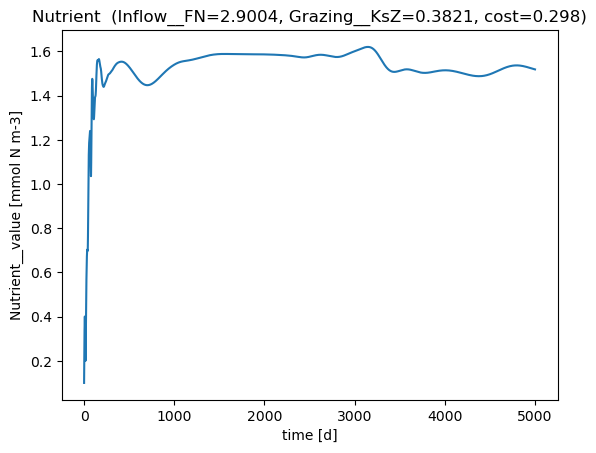

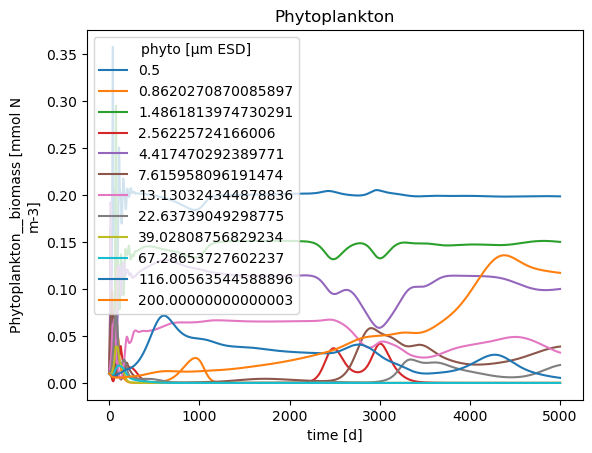

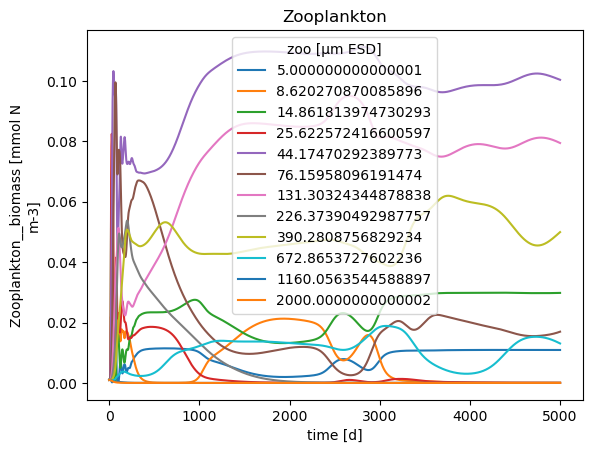

In [20]:
from cariaco_ssm_setup import model_setup_slim
from parscan_utils import run_single_point

best_run = run_single_point(
    model, model_setup_slim,
    scan_params={P1_NAME: best['val1'], P2_NAME: best['val2']},
    fixed_overrides=forcing,
)

best_run['Nutrient__value'].plot.line(x='time')
plt.title(f'Nutrient  ({title_info})')
plt.show()

best_run['Phytoplankton__biomass'].plot.line(x='time')
plt.title('Phytoplankton')
plt.show()

best_run['Zooplankton__biomass'].plot.line(x='time')
plt.title('Zooplankton')
plt.show()

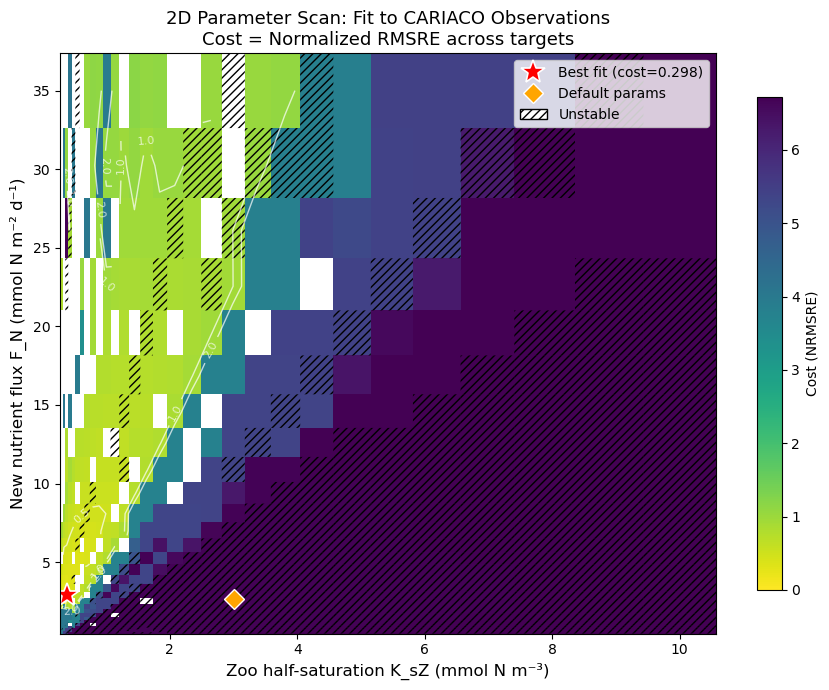

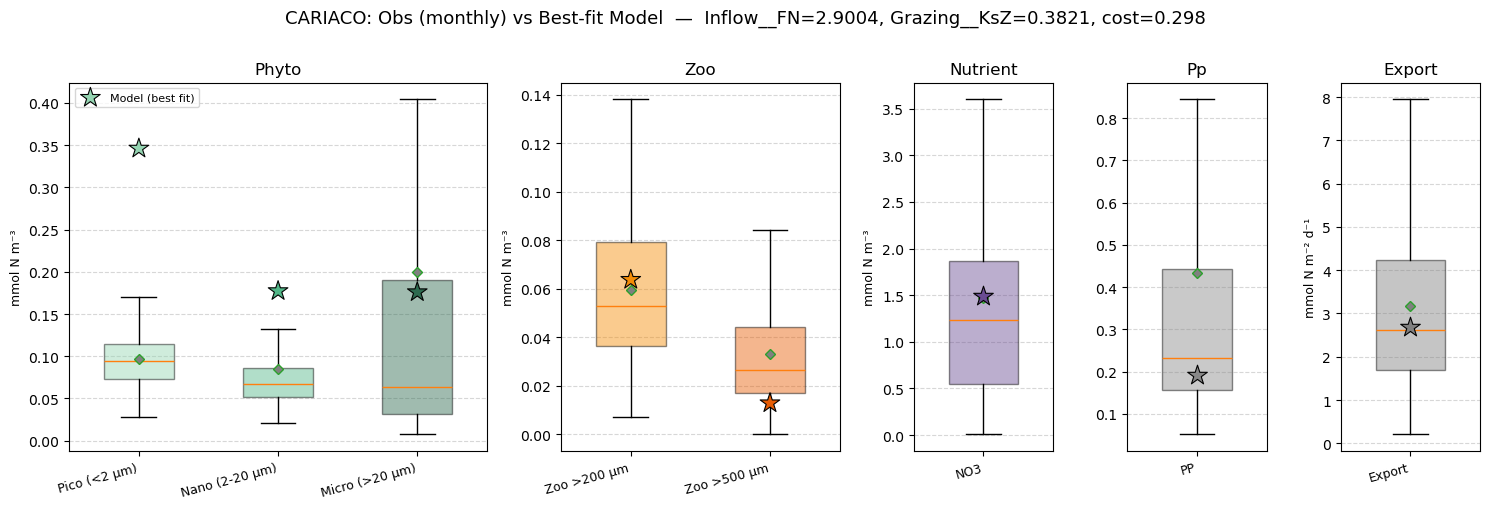

In [21]:
stable_mask = (stability_results['stability'] == 'stable').values

fig1 = plot_cost_heatmap(
    cost_grid, P1_VALUES, P2_VALUES, P1_LABEL, P2_LABEL, best,
    default=default,
    stable_mask=stable_mask,
)
plt.show()

fig3 = plot_model_vs_obs_boxplots(best['model_vec'], monthly_df, bin_defs,
                                  title_info=title_info)
plt.show()

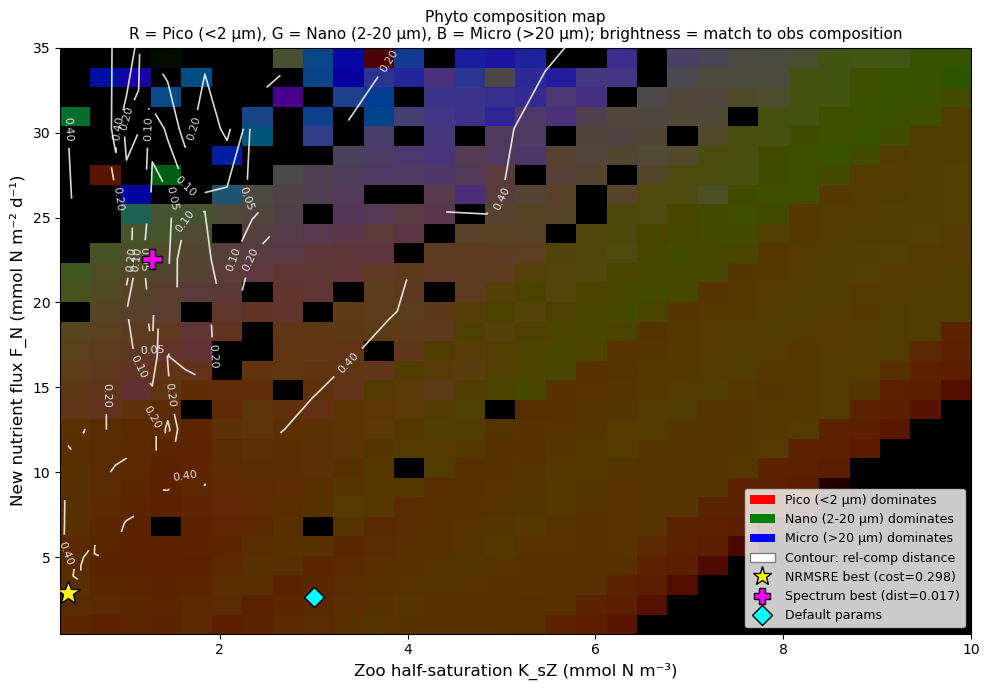

NRMSRE   best:  Inflow__FN=2.9004, Grazing__KsZ=0.3821, cost=0.2978
Spectrum best:  Inflow__FN=22.5526, Grazing__KsZ=1.2802, dist=0.0167


In [22]:
from parscan_utils import compute_spectrum_cost_grid
from parscan_plots import plot_spectrum_composition_map


# New: spectrum-only secondary cost
spectrum_cost_grid = compute_spectrum_cost_grid(
    model_grid, obs_vec, bin_defs, type_filter='phyto')
spectrum_best = find_best_fit(spectrum_cost_grid, model_grid,
                              scan_results, P1_NAME, P2_NAME)

# RGB composition map with both best-fit markers
fig_spec = plot_spectrum_composition_map(
    model_grid, obs_vec, bin_defs,
    P1_VALUES, P2_VALUES, P1_LABEL, P2_LABEL,
    best=best,
    spectrum_best=spectrum_best,
    default=default,
)
plt.show()

# Quick numerical readout of the two minima
print(f"NRMSRE   best:  {P1_NAME}={best['val1']:.4f}, "
      f"{P2_NAME}={best['val2']:.4f}, cost={best['cost']:.4f}")
print(f"Spectrum best:  {P1_NAME}={spectrum_best['val1']:.4f}, "
      f"{P2_NAME}={spectrum_best['val2']:.4f}, "
      f"dist={spectrum_best['cost']:.4f}")

In [23]:
from parscan_plots import summarize_best_fit
summarize_best_fit(
   model_vec=spectrum_best['model_vec'],
   obs_vec=obs_vec,
   labels=labels,
   cost=spectrum_best['cost'],
)


 BEST-FIT SUMMARY  |  Overall cost (NRMSRE): 0.0167
     Component  Obs_Mean  Model_BestFit    Ratio  Rel_Error_%
  Pico (<2 µm)   0.09698        1.54337 15.91466   1491.46572
Nano (2-20 µm)   0.08512        1.22687 14.41418   1341.41814
Micro (>20 µm)   0.19977        3.07141 15.37508   1437.50813
   Zoo >200 µm   0.05938        0.38560  6.49402    549.40232
   Zoo >500 µm   0.03302        0.13855  4.19560    319.55980
           NO3   1.46705        3.87993  2.64471    164.47129
            PP   0.43247        1.41292  3.26709    226.70889
        Export   3.18267       19.73346  6.20029    520.02932


,Component,Obs_Mean,Model_BestFit,Ratio,Rel_Error_%
0,Pico (<2 µm),0.096978,1.543372,15.914657,1491.465716
1,Nano (2-20 µm),0.085116,1.226874,14.414181,1341.418135
2,Micro (>20 µm),0.199765,3.071409,15.375081,1437.508130
3,Zoo >200 µm,0.059377,0.385596,6.494023,549.402316
4,Zoo >500 µm,0.033023,0.138550,4.195598,319.559798
5,NO3,1.467052,3.879931,2.644713,164.471292
6,PP,0.432470,1.412917,3.267089,226.708886
7,Export,3.182666,19.733462,6.200293,520.029321


In [24]:
# Where do both costs sit in their respective "good" regions?
nrmsre_thresh   = np.nanpercentile(cost_grid, 10)            # bottom decile
spectrum_thresh = np.nanpercentile(spectrum_cost_grid, 10)
joint_good      = (cost_grid <= nrmsre_thresh) & \
                  (spectrum_cost_grid <= spectrum_thresh)
print(f"Cells satisfying both bottom-decile thresholds: "
      f"{joint_good.sum()} / {joint_good.size}")

Cells satisfying both bottom-decile thresholds: 16 / 900


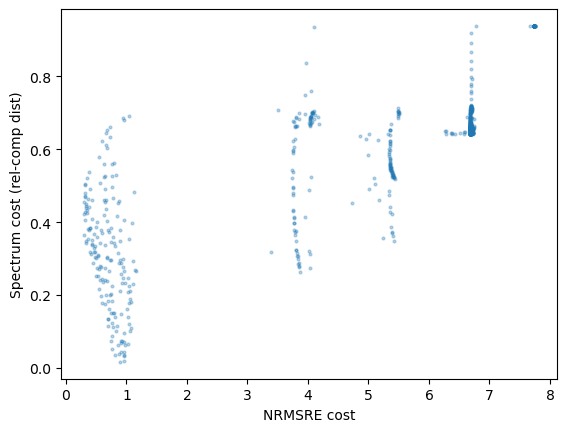

In [25]:
plt.scatter(cost_grid.ravel(), spectrum_cost_grid.ravel(),
            s=4, alpha=0.3)
plt.xlabel('NRMSRE cost'); plt.ylabel('Spectrum cost (rel-comp dist)')
plt.show()

In [26]:
summary = summarize_best_fit(
    model_vec=best['model_vec'],
    obs_vec=obs_vec,
    labels=labels,
    cost=best['cost'],
)


 BEST-FIT SUMMARY  |  Overall cost (NRMSRE): 0.2978
     Component  Obs_Mean  Model_BestFit   Ratio  Rel_Error_%
  Pico (<2 µm)   0.09698        0.34612 3.56911    256.91069
Nano (2-20 µm)   0.08512        0.17732 2.08334    108.33359
Micro (>20 µm)   0.19977        0.17603 0.88118    -11.88173
   Zoo >200 µm   0.05938        0.06380 1.07452      7.45210
   Zoo >500 µm   0.03302        0.01288 0.39011    -60.98913
           NO3   1.46705        1.49472 1.01886      1.88588
            PP   0.43247        0.19106 0.44178    -55.82190
        Export   3.18267        2.67977 0.84199    -15.80117


In [27]:
cell = stability_results.sel({P1_NAME: best['val1'], P2_NAME: best['val2']},
                             method='nearest').isel(time=-1)

# Volumetric rates [mmol N m-3 d-1]
FN_per_de  = float(cell['Inflow__FN']) / float(cell['Inflow__de'])
export_vol = float(cell['DetritusSink__sinking_value'])
fish_P     = float(cell['FishGrazing__fish_graze_phyto_value'].sum('phyto'))
fish_Z     = float(cell['FishGrazing__fish_graze_zoo_value'].sum('zoo'))
zoo_closure_export = float(cell['ZooMortality__mortality_value'].sum('zoo')) \
                   - float(cell['ZooMortality__mortality_to_D_value'])

lhs = FN_per_de
rhs = export_vol + fish_P + fish_Z + zoo_closure_export
print(f"F_N/d_e     = {lhs:.6f}")
print(f"Losses sum  = {rhs:.6f}")
print(f"  sinking       : {export_vol:.6f}")
print(f"  fish on P     : {fish_P:.6f}")
print(f"  fish on Z     : {fish_Z:.6f}")
print(f"  zoo closure   : {zoo_closure_export:.6f}")
print(f"Residual    = {lhs-rhs:.2e}")

# And the f-ratio interpretation:
pp_total = float(cell['Growth__uptake_value'].sum('phyto'))
print(f"\nTotal PP    = {pp_total:.6f}")
print(f"New PP      = {FN_per_de:.6f}  (≡ F_N/d_e)")
print(f"Regen PP    = {pp_total - FN_per_de:.6f}")
print(f"f-ratio     = {FN_per_de / pp_total:.3f}")

F_N/d_e     = 0.063638
Losses sum  = 0.063638
  sinking       : 0.058797
  fish on P     : 0.000199
  fish on Z     : 0.000153
  zoo closure   : 0.004489
Residual    = -4.91e-15

Total PP    = 0.191057
New PP      = 0.063638  (≡ F_N/d_e)
Regen PP    = 0.127419
f-ratio     = 0.333
